# CellFlow sanity check — checkpoint analysis

Analyze outputs from `sanity_check_cf.py` across:
- **obsm keys**: X_pca, X_state (and later X_scconcept, X_scgpt, X_scimilarity)
- **presets**: deterministic (eps=0.01, noise=0.0) vs noisy (eps=10.0, noise=0.1)

Sections:
1. **Data loading**: discover available runs, load CSVs
2. **MMD at best checkpoint**: bar chart across runs
3. **MMD along training**: per-condition traces + mean curves
4. **Perturbation strength vs prediction quality**: MMD(ctrl,tgt) vs MMD(pred,tgt)
5. **Control MMD vs target MMD scatter per step**
6. **Cross-run comparison table**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, linregress
import scanpy as sc
plt.rcParams.update({"figure.dpi": 150, "axes.spines.top": False, "axes.spines.right": False})

/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


## 0. Datasets sanity check

In [2]:
DATASETS = {
    "tahoe": "/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_a549_w_emb.h5ad"
}
adata = sc.read_h5ad(DATASETS["tahoe"])



In [3]:
import cellflow.preprocessing as cfpp
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
cfpp.centered_pca(adata_hvg, n_comps=100, method="scanpy",
                    keep_centered_data=False)
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.uns["pca"] = adata_hvg.uns["pca"]
adata.varm["PCs"] = np.zeros((adata.n_vars, 100))
adata.varm["PCs"][adata.var["highly_variable"].values] = adata_hvg.varm["PCs"]
adata.varm["X_mean"] = np.zeros((adata.n_vars, 1))
adata.varm["X_mean"][adata.var["highly_variable"].values] = adata_hvg.varm["X_mean"]


ERROR:2026-03-18 15:28:41,324:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable

PC variance: n_comps=100
  Per-PC variance ratio: min=0.0026, max=0.0578
  Cumulative: 10 PCs = 18.55%, 50 PCs = 36.73%, 100 PCs = 51.94%


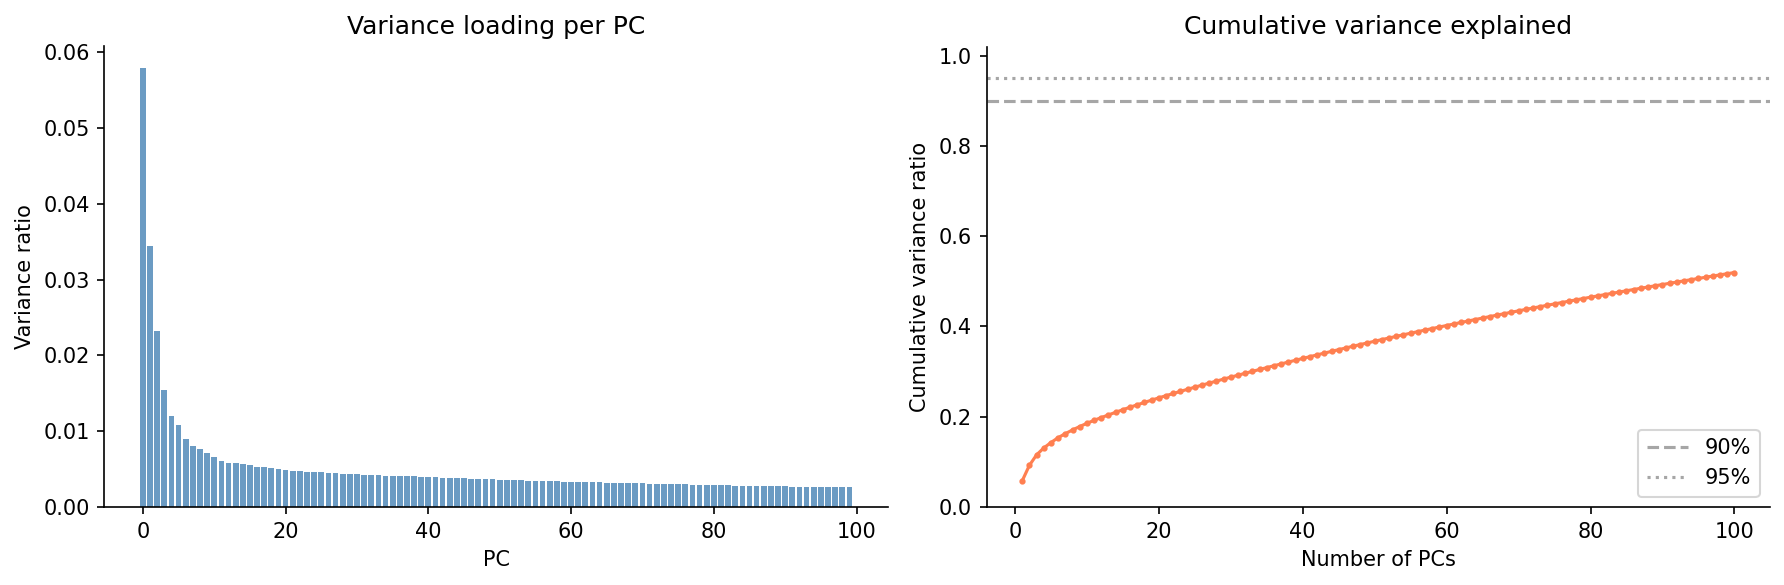

In [5]:
# Variance loading of PCs (from adata.uns["pca"] after PCA cell above)
pca_uns = adata.uns.get("pca", {})
var_ratio = pca_uns.get("variance_ratio")
variance = pca_uns.get("variance")

if var_ratio is not None:
    var_ratio = np.asarray(var_ratio).ravel()
    n_pcs = len(var_ratio)
    cumvar = np.cumsum(var_ratio)

    print(f"PC variance: n_comps={n_pcs}")
    print(f"  Per-PC variance ratio: min={var_ratio.min():.4f}, max={var_ratio.max():.4f}")
    print(f"  Cumulative: 10 PCs = {cumvar[9]:.2%}, 50 PCs = {cumvar[49]:.2%}, 100 PCs = {cumvar[-1]:.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(range(n_pcs), var_ratio, width=0.8, color="steelblue", alpha=0.8)
    axes[0].set_xlabel("PC")
    axes[0].set_ylabel("Variance ratio")
    axes[0].set_title("Variance loading per PC")

    axes[1].plot(range(1, n_pcs + 1), cumvar, "o-", markersize=2, color="coral")
    axes[1].axhline(0.9, color="gray", ls="--", alpha=0.7, label="90%")
    axes[1].axhline(0.95, color="gray", ls=":", alpha=0.7, label="95%")
    axes[1].set_xlabel("Number of PCs")
    axes[1].set_ylabel("Cumulative variance ratio")
    axes[1].set_title("Cumulative variance explained")
    axes[1].legend()
    axes[1].set_ylim(0, 1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No variance_ratio in adata.uns['pca']. Run the PCA cell above first.")

In [11]:
# Variance of the mean X_pca (mean cell in PCA space, then variance across dimensions)
X_pca = np.asarray(adata.obsm["X_pca"])
mean_x_pca = X_pca.mean(axis=0)  # (n_comps,) mean cell in PCA space
var_of_mean = np.var(mean_x_pca)  # variance of that mean vector across PC dimensions

print("Mean X_pca (mean across cells, shape {}):".format(mean_x_pca.shape))
print("  Variance of mean vector (across PC dims): {}".format(var_of_mean))
print("  Std of mean vector: {}".format(np.sqrt(var_of_mean)))
print("  Min/max of mean vector: {} / {}".format(mean_x_pca.min(), mean_x_pca.max()))

# For context: variance per PC (across cells) vs mean's contribution
var_per_pc = np.var(X_pca, axis=0)
print("\nPer-PC variance (across cells): sum = {:.4f}".format(var_per_pc.sum()))

Mean X_pca (mean across cells, shape (100,)):
  Variance of mean vector (across PC dims): 4.3744330380235397e-10
  Std of mean vector: 2.091514579660725e-05
  Min/max of mean vector: -5.6177312217187136e-05 / 6.452879460994154e-05

Per-PC variance (across cells): sum = 132.1294


In [10]:
np.var(X_pca.mean(axis=0))

np.float32(4.374433e-10)

In [18]:
X_scconcept = np.asarray(adata.obsm["X_scgpt"])
mean_x_scconcept = X_scconcept.mean(axis=0)  #
var_of_mean_scconcept = np.var(mean_x_scconcept)  # variance of that mean vector across PC dimensions

print("Mean X_scconcept (mean across cells, shape {}):".format(mean_x_scconcept.shape))
print("  Variance of mean vector (across PC dims): {}".format(var_of_mean_scconcept))
print("  Std of mean vector: {}".format(np.sqrt(var_of_mean_scconcept)))
print("  Min/max of mean vector: {} / {}".format(mean_x_scconcept.min(), mean_x_scconcept.max()))


Mean X_scconcept (mean across cells, shape (512,)):
  Variance of mean vector (across PC dims): 0.0018712027231231332
  Std of mean vector: 0.04325740039348602
  Min/max of mean vector: -0.4788871109485626 / 0.5374093651771545


## 1. Discover runs & load CSVs

In [2]:
BASE = Path("/lustre/groups/ml01/workspace/xiaotong.fu/pancellflow/outputs/sanity_check_cf/tahoe")

OBSM_KEYS = ["X_pca", "X_state", "X_scconcept", "X_scgpt", "X_scimilarity"]
PRESETS = ["deterministic", "noisy"]

runs = {}
for key in OBSM_KEYS:
    for preset in PRESETS:
        run_dir = BASE / key / preset
        tag = f"{key}/{preset}"
        files = {}
        for fname in ["mmd_best.csv", "mmd_along_training.csv", "mmd_baseline.csv"]:
            p = run_dir / fname
            if p.exists():
                files[fname] = pd.read_csv(p)
        if files:
            runs[tag] = files
            status = ", ".join(f"{k} ({len(v)} rows)" for k, v in files.items())
            print(f"  {tag:>35s}  =>  {status}")
        else:
            print(f"  {tag:>35s}  =>  [not ready]")

print(f"\n{len(runs)} runs loaded")

                  X_pca/deterministic  =>  [not ready]
                          X_pca/noisy  =>  [not ready]
                X_state/deterministic  =>  [not ready]
                        X_state/noisy  =>  [not ready]
            X_scconcept/deterministic  =>  [not ready]
                    X_scconcept/noisy  =>  [not ready]
                X_scgpt/deterministic  =>  [not ready]
                        X_scgpt/noisy  =>  [not ready]
          X_scimilarity/deterministic  =>  [not ready]
                  X_scimilarity/noisy  =>  [not ready]

0 runs loaded


## 2. MMD at best checkpoint — bar chart across runs

In [3]:
best_runs = {tag: r["mmd_best.csv"] for tag, r in runs.items() if "mmd_best.csv" in r}
if not best_runs:
    print("No mmd_best.csv found yet — jobs may still be running.")
else:
    summary = []
    for tag, df in best_runs.items():
        summary.append({
            "run": tag,
            "mean_mmd_pred_tgt": df.mmd_pred_tgt.mean(),
            "median_mmd_pred_tgt": df.mmd_pred_tgt.median(),
            "mean_mmd_pred_ctrl": df.mmd_pred_ctrl.mean(),
            "median_mmd_pred_ctrl": df.mmd_pred_ctrl.median(),
            "n_conditions": len(df),
        })
    df_summary = pd.DataFrame(summary).sort_values("mean_mmd_pred_tgt")
    display(df_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = range(len(df_summary))
    labels = df_summary["run"].values

    axes[0].barh(x, df_summary["mean_mmd_pred_tgt"], color="#3498db", alpha=0.8)
    axes[0].set_yticks(x); axes[0].set_yticklabels(labels)
    axes[0].set_xlabel("Mean MMD(pred, tgt)"); axes[0].set_title("Best checkpoint: MMD to target")

    axes[1].barh(x, df_summary["mean_mmd_pred_ctrl"], color="#e74c3c", alpha=0.8)
    axes[1].set_yticks(x); axes[1].set_yticklabels(labels)
    axes[1].set_xlabel("Mean MMD(pred, ctrl)"); axes[1].set_title("Best checkpoint: MMD to control")

    plt.tight_layout()
    plt.show()

No mmd_best.csv found yet — jobs may still be running.


## 3. MMD along training — per-condition traces + mean curves

In [4]:
along_runs = {tag: r["mmd_along_training.csv"] for tag, r in runs.items() if "mmd_along_training.csv" in r}
if not along_runs:
    print("No mmd_along_training.csv found yet.")
else:
    n_runs = len(along_runs)
    fig, axes = plt.subplots(n_runs, 3, figsize=(18, 5 * n_runs), squeeze=False)

    for row, (tag, ma) in enumerate(sorted(along_runs.items())):
        steps = sorted(ma.checkpoint_step.unique())

        # Col 0: Per-condition MMD(pred, tgt)
        ax = axes[row, 0]
        for _, g in ma.groupby("condition_key"):
            ax.plot(g.checkpoint_step, g.mmd_pred_tgt, color="C0", alpha=0.05, lw=0.5)
        m = ma.groupby("checkpoint_step").mmd_pred_tgt.mean()
        ax.plot(m.index, m.values, "o-", color="C0", lw=2, label="Mean", zorder=5)
        ax.set_xlabel("Step"); ax.set_ylabel("MMD(pred, target)")
        ax.set_title(f"{tag}: MMD(pred, tgt)"); ax.legend()

        # Col 1: Per-condition MMD(pred, ctrl)
        ax = axes[row, 1]
        for _, g in ma.groupby("condition_key"):
            ax.plot(g.checkpoint_step, g.mmd_pred_ctrl, color="C1", alpha=0.05, lw=0.5)
        m = ma.groupby("checkpoint_step").mmd_pred_ctrl.mean()
        ax.plot(m.index, m.values, "o-", color="C1", lw=2, label="Mean", zorder=5)
        ax.set_xlabel("Step"); ax.set_ylabel("MMD(pred, control)")
        ax.set_title(f"{tag}: MMD(pred, ctrl)"); ax.legend()

        # Col 2: Sum per step
        ax = axes[row, 2]
        s1 = ma.groupby("checkpoint_step").mmd_pred_tgt.sum()
        s2 = ma.groupby("checkpoint_step").mmd_pred_ctrl.sum()
        ax.plot(s1.index, s1.values, "o-", color="C0", label="\u2211 MMD(pred,tgt)")
        ax.plot(s2.index, s2.values, "s-", color="C1", label="\u2211 MMD(pred,ctrl)")
        ax.set_xlabel("Step"); ax.set_ylabel("Sum")
        ax.set_title(f"{tag}: sum MMDs"); ax.legend()

    plt.tight_layout()
    plt.show()

No mmd_along_training.csv found yet.


## 3b. Overlay mean MMD(pred, tgt) across all runs

In [5]:
if along_runs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(along_runs)))

    for i, (tag, ma) in enumerate(sorted(along_runs.items())):
        m_tgt = ma.groupby("checkpoint_step").mmd_pred_tgt.mean()
        m_ctrl = ma.groupby("checkpoint_step").mmd_pred_ctrl.mean()
        axes[0].plot(m_tgt.index, m_tgt.values, "o-", label=tag, color=colors[i], lw=2)
        axes[1].plot(m_ctrl.index, m_ctrl.values, "s-", label=tag, color=colors[i], lw=2)

    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Mean MMD(pred, tgt)")
    axes[0].set_title("All runs: MMD(pred, tgt) over training"); axes[0].legend(fontsize=7)
    axes[1].set_xlabel("Step"); axes[1].set_ylabel("Mean MMD(pred, ctrl)")
    axes[1].set_title("All runs: MMD(pred, ctrl) over training"); axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## 4. Perturbation strength vs prediction quality

Scatter MMD(ctrl, tgt) vs MMD(pred, tgt) at best checkpoint — are harder perturbations harder to predict?

In [6]:
baseline_runs = {tag: r["mmd_baseline.csv"] for tag, r in runs.items() if "mmd_baseline.csv" in r}
runs_with_both = [tag for tag in best_runs if tag in baseline_runs]

if not runs_with_both:
    print("Need both mmd_best.csv and mmd_baseline.csv.")
else:
    n = len(runs_with_both)
    cols = min(n, 3)
    rows_fig = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_fig, cols, figsize=(6 * cols, 5 * rows_fig), squeeze=False)

    for idx, tag in enumerate(sorted(runs_with_both)):
        ax = axes[idx // cols, idx % cols]
        df_best = best_runs[tag]
        df_bl = baseline_runs[tag]
        merged = df_best.merge(df_bl, on="condition_key", how="inner")

        x = merged["mmd_ctrl_tgt"]
        y = merged["mmd_pred_tgt"]
        ax.scatter(x, y, alpha=0.4, s=12, color="#3498db")

        lim = max(x.max(), y.max()) * 1.05
        ax.plot([0, lim], [0, lim], "k--", alpha=0.4, lw=1, label="y=x (no improvement)")

        rp, _ = pearsonr(x, y)
        ax.set_xlabel("MMD(ctrl, tgt) — perturbation strength")
        ax.set_ylabel("MMD(pred, tgt) — prediction error")
        ax.set_title(f"{tag}\nr={rp:.3f}, n={len(merged)}")
        ax.legend(fontsize=8)

    for idx in range(n, rows_fig * cols):
        axes[idx // cols, idx % cols].set_visible(False)
    plt.tight_layout()
    plt.show()

Need both mmd_best.csv and mmd_baseline.csv.


## 5. Control MMD vs Target MMD scatter per checkpoint step

In [7]:
for tag in sorted(along_runs):
    ma = along_runs[tag]
    steps = sorted(ma.checkpoint_step.unique())
    n_steps = len(steps)

    fig, axes = plt.subplots(1, n_steps, figsize=(5 * n_steps, 5))
    if n_steps == 1:
        axes = [axes]

    for col, step in enumerate(steps):
        ax = axes[col]
        sd = ma[ma.checkpoint_step == step]
        x = sd["mmd_pred_ctrl"]
        y = sd["mmd_pred_tgt"]

        if len(x) > 1:
            slope, intercept, r_val, _, _ = linregress(x, y)
            x_fit = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, "r-", alpha=0.6, lw=1.5,
                    label=f"r={r_val:.3f}")

        ax.scatter(x, y, s=15, alpha=0.5, edgecolors="white", linewidth=0.3, color="#3498db")
        ax.set_xlabel("MMD(pred, ctrl)")
        ax.set_ylabel("MMD(pred, tgt)")
        ax.set_title(f"Step {step}")
        ax.legend(fontsize=8)

    fig.suptitle(f"{tag}: pred-ctrl vs pred-tgt per step", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 5b. Perturbation strength vs prediction quality — per step

MMD(ctrl, tgt) vs MMD(pred, tgt) at each checkpoint step. Points below the y=x line indicate the model is improving over the "return control unchanged" baseline.

In [8]:
for tag in sorted(runs_with_both):
    if tag not in along_runs:
        continue
    ma = along_runs[tag]
    df_bl = baseline_runs[tag]

    # Also include best checkpoint if available
    steps = sorted(ma.checkpoint_step.unique())
    has_best = tag in best_runs
    plot_steps = steps + (["best"] if has_best else [])
    n_steps = len(plot_steps)

    fig, axes = plt.subplots(1, n_steps, figsize=(5 * n_steps, 5))
    if n_steps == 1:
        axes = [axes]

    for col, step in enumerate(plot_steps):
        ax = axes[col]
        if step == "best":
            sd = best_runs[tag].merge(df_bl, on="condition_key", how="inner")
        else:
            sd = ma[ma.checkpoint_step == step].merge(df_bl, on="condition_key", how="inner")

        x = sd["mmd_ctrl_tgt"]
        y = sd["mmd_pred_tgt"]

        ax.scatter(x, y, s=15, alpha=0.5, edgecolors="white", linewidth=0.3, color="#3498db")
        lim = max(x.max(), y.max()) * 1.05
        ax.plot([0, lim], [0, lim], "k--", alpha=0.4, lw=1, label="y=x")

        frac_below = (y < x).mean()
        if len(x) > 1:
            rp, _ = pearsonr(x, y)
            ax.set_title(f"Step {step}\nr={rp:.3f}, {frac_below:.0%} below y=x")
        else:
            ax.set_title(f"Step {step}")
        ax.set_xlabel("MMD(ctrl, tgt)")
        ax.set_ylabel("MMD(pred, tgt)")
        ax.legend(fontsize=7)

    fig.suptitle(f"{tag}: perturbation strength vs prediction error", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Cross-run comparison — summary table

Per-step mean MMD for all runs side by side, plus gap closure ratio.

In [9]:
table_rows = []
for tag in sorted(runs):
    bl_mean = None
    if tag in baseline_runs:
        bl_mean = baseline_runs[tag].mmd_ctrl_tgt.mean()

    if tag in along_runs:
        ma = along_runs[tag]
        for step in sorted(ma.checkpoint_step.unique()):
            sd = ma[ma.checkpoint_step == step]
            mpt = sd.mmd_pred_tgt.mean()
            mpc = sd.mmd_pred_ctrl.mean()
            gc = (1 - mpt / bl_mean) if bl_mean and bl_mean > 1e-8 else None
            table_rows.append({
                "run": tag, "step": step,
                "mean_mmd_pred_tgt": mpt, "mean_mmd_pred_ctrl": mpc,
                "baseline_mmd_ctrl_tgt": bl_mean,
                "gap_closure": gc,
            })

    if tag in best_runs:
        df_b = best_runs[tag]
        mpt = df_b.mmd_pred_tgt.mean()
        mpc = df_b.mmd_pred_ctrl.mean()
        gc = (1 - mpt / bl_mean) if bl_mean and bl_mean > 1e-8 else None
        table_rows.append({
            "run": tag, "step": "best",
            "mean_mmd_pred_tgt": mpt, "mean_mmd_pred_ctrl": mpc,
            "baseline_mmd_ctrl_tgt": bl_mean,
            "gap_closure": gc,
        })

if table_rows:
    df_table = pd.DataFrame(table_rows)
    pd.set_option("display.float_format", "{:.5f}".format)
    display(df_table)
    pd.reset_option("display.float_format")
else:
    print("No data available yet.")

No data available yet.


## 7. Gap closure heatmap

`gap_closure = 1 - MMD(pred, tgt) / MMD(ctrl, tgt)`:  1.0 = perfect, 0.0 = trivial (pred == ctrl), < 0 = worse than returning control unchanged.

In [10]:
if table_rows:
    df_gc = df_table[df_table.gap_closure.notna()].copy()
    df_gc["step"] = df_gc["step"].astype(str)
    pivot = df_gc.pivot(index="run", columns="step", values="gap_closure")

    step_order = [str(s) for s in sorted([int(c) for c in pivot.columns if c != "best"])] + (["best"] if "best" in pivot.columns else [])
    pivot = pivot[step_order]

    fig, ax = plt.subplots(figsize=(max(8, len(step_order) * 1.5), max(3, len(pivot) * 0.8)))
    im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-0.5, vmax=1.0)

    ax.set_xticks(range(len(step_order))); ax.set_xticklabels(step_order)
    ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Checkpoint step"); ax.set_ylabel("Run")
    ax.set_title("Gap closure ratio")

    for i in range(len(pivot)):
        for j in range(len(step_order)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        color="black" if 0.2 < val < 0.8 else "white", fontsize=9)

    plt.colorbar(im, ax=ax, label="Gap closure")
    plt.tight_layout()
    plt.show()

## 8. Per-condition distribution of MMD(pred, tgt) at best checkpoint

In [11]:
if best_runs:
    n = len(best_runs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    for idx, (tag, df) in enumerate(sorted(best_runs.items())):
        ax = axes[0, idx]
        ax.hist(df.mmd_pred_tgt, bins=50, alpha=0.7, color="#3498db", edgecolor="white", label="MMD(pred,tgt)")
        ax.hist(df.mmd_pred_ctrl, bins=50, alpha=0.5, color="#e74c3c", edgecolor="white", label="MMD(pred,ctrl)")
        ax.axvline(df.mmd_pred_tgt.mean(), color="#2c3e50", ls="--", lw=1.5, label=f"mean={df.mmd_pred_tgt.mean():.4f}")
        ax.set_xlabel("MMD"); ax.set_ylabel("Count")
        ax.set_title(tag); ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## 9. Load best checkpoint directly — ad-hoc prediction + pushing analysis

Rebuild the CellFlow model, inject best checkpoint params, predict all conditions, and compute:
- Per-condition R² (on mean vectors) and MMD(pred, tgt), MMD(pred, ctrl)
- "Pushing" analysis: does the model actually move cells away from control towards target?
  - Scatter: MMD(ctrl, tgt) vs MMD(pred, tgt) — below y=x = model beats "return control"
  - Delta table: MMD(pred, tgt) - MMD(ctrl, tgt) — negative = improvement

In [12]:
# ── 9a. Pick which run to analyze ──
RUN_TAG = "X_state/deterministic"  # change this to analyze a different run
RUN_DIR = BASE / RUN_TAG

CKPT_PATH = RUN_DIR / "best_checkpoint.pkl"
assert CKPT_PATH.exists(), f"No best_checkpoint.pkl at {CKPT_PATH}"
print(f"Analyzing: {RUN_TAG}")
print(f"  Checkpoint: {CKPT_PATH}")

Analyzing: X_state/deterministic
  Checkpoint: /lustre/groups/ml01/workspace/xiaotong.fu/pancellflow/outputs/sanity_check_cf/tahoe/X_state/deterministic/best_checkpoint.pkl


In [13]:
# ── 9b. Rebuild CellFlow model + load checkpoint ──
import cloudpickle
import scanpy as sc
import jax
import optax
from functools import partial

import cellflow.preprocessing as cfpp
from cellflow.model import CellFlow
from cellflow.metrics import compute_scalar_mmd
from cellflow.utils import match_linear
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

DATASET_PATH = "/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_a549_w_emb.h5ad"
OBSM_KEY = RUN_TAG.split("/")[0]  # e.g. "X_pca"
EPSILON = 0.01 if "deterministic" in RUN_TAG else 10.0
NOISE = 0.0 if "deterministic" in RUN_TAG else 0.1

print(f"Loading adata ...")
adata = sc.read_h5ad(DATASET_PATH)
ctrl_mask = (adata.obs["drug_0"] == "control") & (adata.obs["drug_1"] == "control")
adata.obs["control"] = ctrl_mask
print(f"  {adata.n_obs} cells, {adata.n_vars} genes")

if OBSM_KEY == "X_pca":
    print("Computing PCA-100 ...")
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata_hvg = adata[:, adata.var["highly_variable"]].copy()
    cfpp.centered_pca(adata_hvg, n_comps=100, method="scanpy", keep_centered_data=False)
    adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
    adata.uns["pca"] = adata_hvg.uns["pca"]
    del adata_hvg
    sample_rep = "X_pca"
else:
    sample_rep = OBSM_KEY

print(f"  Cell rep: {sample_rep}, dim={adata.obsm[sample_rep].shape[1]}")

cfpp.encode_onehot(adata, covariate_keys=["drug_0", "drug_1"], uns_key_added="drug_onehot")
print(f"  {len(adata.uns['drug_onehot'])} drugs one-hot encoded")

cf = CellFlow(adata, solver="otfm")
cf.prepare_data(
    sample_rep=sample_rep,
    control_key="control",
    perturbation_covariates={"drug_treatment": ("drug_0", "drug_1")},
    perturbation_covariate_reps={"drug_treatment": "drug_onehot"},
    max_combination_length=2,
    null_value=0.0,
)

cf.prepare_model(
    condition_mode="deterministic",
    pooling="mean",
    layers_before_pool=[{"layer_type": "mlp", "dims": [1024, 1024], "dropout_rate": 0.0}],
    condition_embedding_dim=256,
    cond_output_dropout=0.0,
    hidden_dims=(1024, 1024),
    hidden_dropout=0.0,
    conditioning="concatenation",
    decoder_dims=(1024, 1024),
    decoder_dropout=0.0,
    probability_path={"constant_noise": NOISE},
    match_fn=partial(match_linear, epsilon=EPSILON),
    optimizer=optax.MultiSteps(optax.adam(learning_rate=1e-4), 20),
    seed=42,
)

total_params = sum(x.size for x in jax.tree_util.tree_leaves(cf._solver.vf_state.params))
print(f"  Model: {total_params:,} params")

with open(CKPT_PATH, "rb") as f:
    best_params = cloudpickle.load(f)
cf._solver.vf_state = cf._solver.vf_state.replace(params=best_params)
cf._solver.vf_state_inference = cf._solver.vf_state_inference.replace(params=best_params)
print("  Best checkpoint loaded.")

/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading adata ...
  2326890 cells, 62710 genes
  Cell rep: X_state, dim=2058
  368 drugs one-hot encoded
[########################################] | 100% Completed | 109.33 ms
[########################################] | 100% Completed | 1.24 sms
[########################################] | 100% Completed | 104.89 ms
  Model: 21,907,722 params
  Best checkpoint loaded.


In [14]:
# ── 9c. Build per-condition dicts (src, tgt, cond) from TrainingData ──
td = cf.train_data

ptb_to_ctrl = {}
for ctrl_idx, ptb_indices in td.control_to_perturbation.items():
    for pidx in ptb_indices:
        ptb_to_ctrl[pidx] = ctrl_idx

src_dict, tgt_dict, cond_dict = {}, {}, {}
for ptb_idx in range(td.n_perturbations):
    ctrl_idx = ptb_to_ctrl.get(ptb_idx)
    if ctrl_idx is None:
        continue
    cov = td.perturbation_idx_to_covariates[ptb_idx]
    key = "|".join(str(c) for c in cov)
    src_dict[key] = td.cell_data[td.split_covariates_mask == ctrl_idx]
    tgt_dict[key] = td.cell_data[td.perturbation_covariates_mask == ptb_idx]
    cond_dict[key] = {k: v[[ptb_idx]] for k, v in td.condition_data.items()}

print(f"{len(src_dict)} perturbation conditions")

367 perturbation conditions


In [15]:
# ── 9d. Ad-hoc prediction: R², MMD(pred,tgt), MMD(pred,ctrl), MMD(ctrl,tgt) ──
MAX_CELLS = 512
rng_p = np.random.default_rng(42)

def _sub(arr, max_n=MAX_CELLS):
    if arr.shape[0] <= max_n:
        return arr
    return arr[rng_p.choice(arr.shape[0], max_n, replace=False)]

records = []
for key in tqdm(src_dict, desc="Predicting"):
    drug = key.split("|")[0]
    src = _sub(src_dict[key])
    tgt = _sub(tgt_dict[key])
    pred = np.array(cf._solver.predict(src, condition=cond_dict[key]))

    r2 = r2_score(tgt.mean(axis=0), pred.mean(axis=0))
    mmd_pt = float(compute_scalar_mmd(pred, tgt))
    mmd_pc = float(compute_scalar_mmd(pred, src))
    mmd_ct = float(compute_scalar_mmd(src, tgt))

    records.append({
        "drug_0": drug, "condition_key": key,
        "r_squared": r2,
        "mmd_pred_tgt": mmd_pt,
        "mmd_pred_ctrl": mmd_pc,
        "mmd_ctrl_tgt": mmd_ct,
    })

df_adhoc = pd.DataFrame(records)
print(f"\n{len(df_adhoc)} conditions predicted")
print(f"  R²(mean):      {df_adhoc.r_squared.mean():.4f}  (median {df_adhoc.r_squared.median():.4f})")
print(f"  MMD(pred,tgt):  {df_adhoc.mmd_pred_tgt.mean():.5f}")
print(f"  MMD(pred,ctrl): {df_adhoc.mmd_pred_ctrl.mean():.5f}")
print(f"  MMD(ctrl,tgt):  {df_adhoc.mmd_ctrl_tgt.mean():.5f}  (baseline)")
delta = df_adhoc.mmd_pred_tgt.mean() - df_adhoc.mmd_ctrl_tgt.mean()
print(f"  Δ (pred-baseline): {delta:+.5f}  {'[worse]' if delta > 0 else '[better]'}")

Predicting: 100%|██████████| 367/367 [04:49<00:00,  1.27it/s]



367 conditions predicted
  R²(mean):      0.9632  (median 0.9696)
  MMD(pred,tgt):  0.00444
  MMD(pred,ctrl): 0.00115
  MMD(ctrl,tgt):  0.00402  (baseline)
  Δ (pred-baseline): +0.00043  [worse]


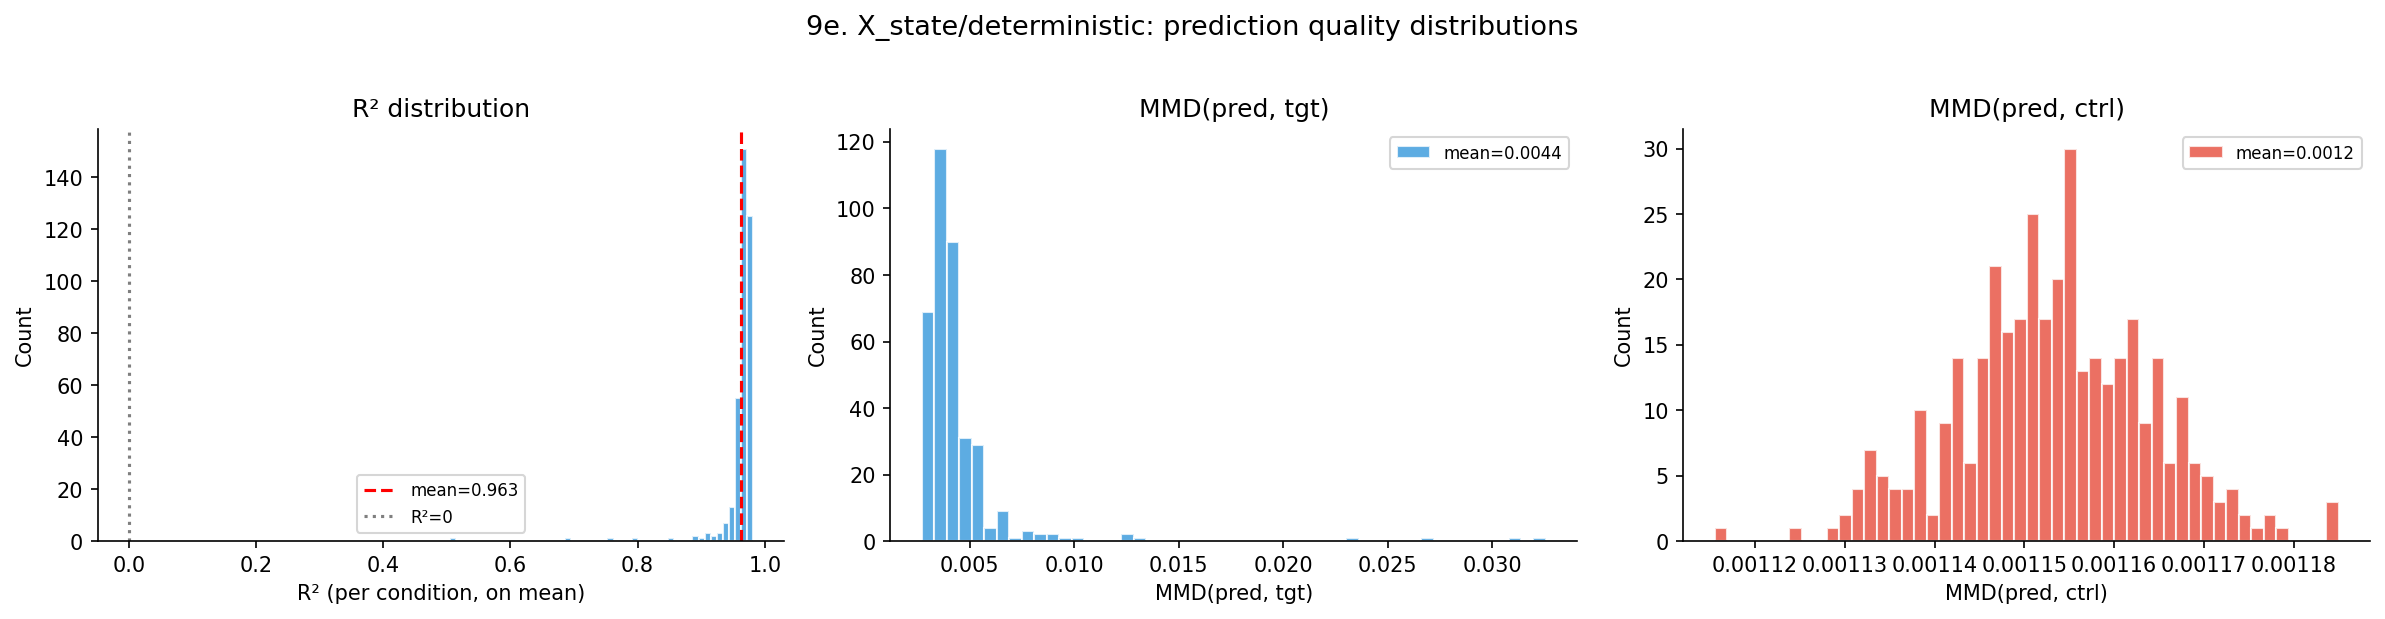

In [16]:
# ── 9e. Prediction distributions: R², MMD(pred,tgt), MMD(pred,ctrl) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_adhoc.r_squared, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(df_adhoc.r_squared.mean(), color="red", ls="--", lw=1.5,
                label=f"mean={df_adhoc.r_squared.mean():.3f}")
axes[0].axvline(0, color="k", ls=":", alpha=0.5, label="R²=0")
axes[0].set_xlabel("R² (per condition, on mean)"); axes[0].set_ylabel("Count")
axes[0].set_title("R² distribution"); axes[0].legend(fontsize=8)

axes[1].hist(df_adhoc.mmd_pred_tgt, bins=50, color="#3498db", edgecolor="white", alpha=0.8,
             label=f"mean={df_adhoc.mmd_pred_tgt.mean():.4f}")
axes[1].set_xlabel("MMD(pred, tgt)"); axes[1].set_ylabel("Count")
axes[1].set_title("MMD(pred, tgt)"); axes[1].legend(fontsize=8)

axes[2].hist(df_adhoc.mmd_pred_ctrl, bins=50, color="#e74c3c", edgecolor="white", alpha=0.8,
             label=f"mean={df_adhoc.mmd_pred_ctrl.mean():.4f}")
axes[2].set_xlabel("MMD(pred, ctrl)"); axes[2].set_ylabel("Count")
axes[2].set_title("MMD(pred, ctrl)"); axes[2].legend(fontsize=8)

fig.suptitle(f"9e. {RUN_TAG}: prediction quality distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 9f. Pushing analysis — is the model actually moving cells towards target?

- **Scatter**: MMD(ctrl, tgt) vs MMD(pred, tgt). Points below y=x = model beats "return control".
- **Bar**: gap closure = 1 - MMD(pred,tgt) / MMD(ctrl,tgt). Values > 0 = improvement.

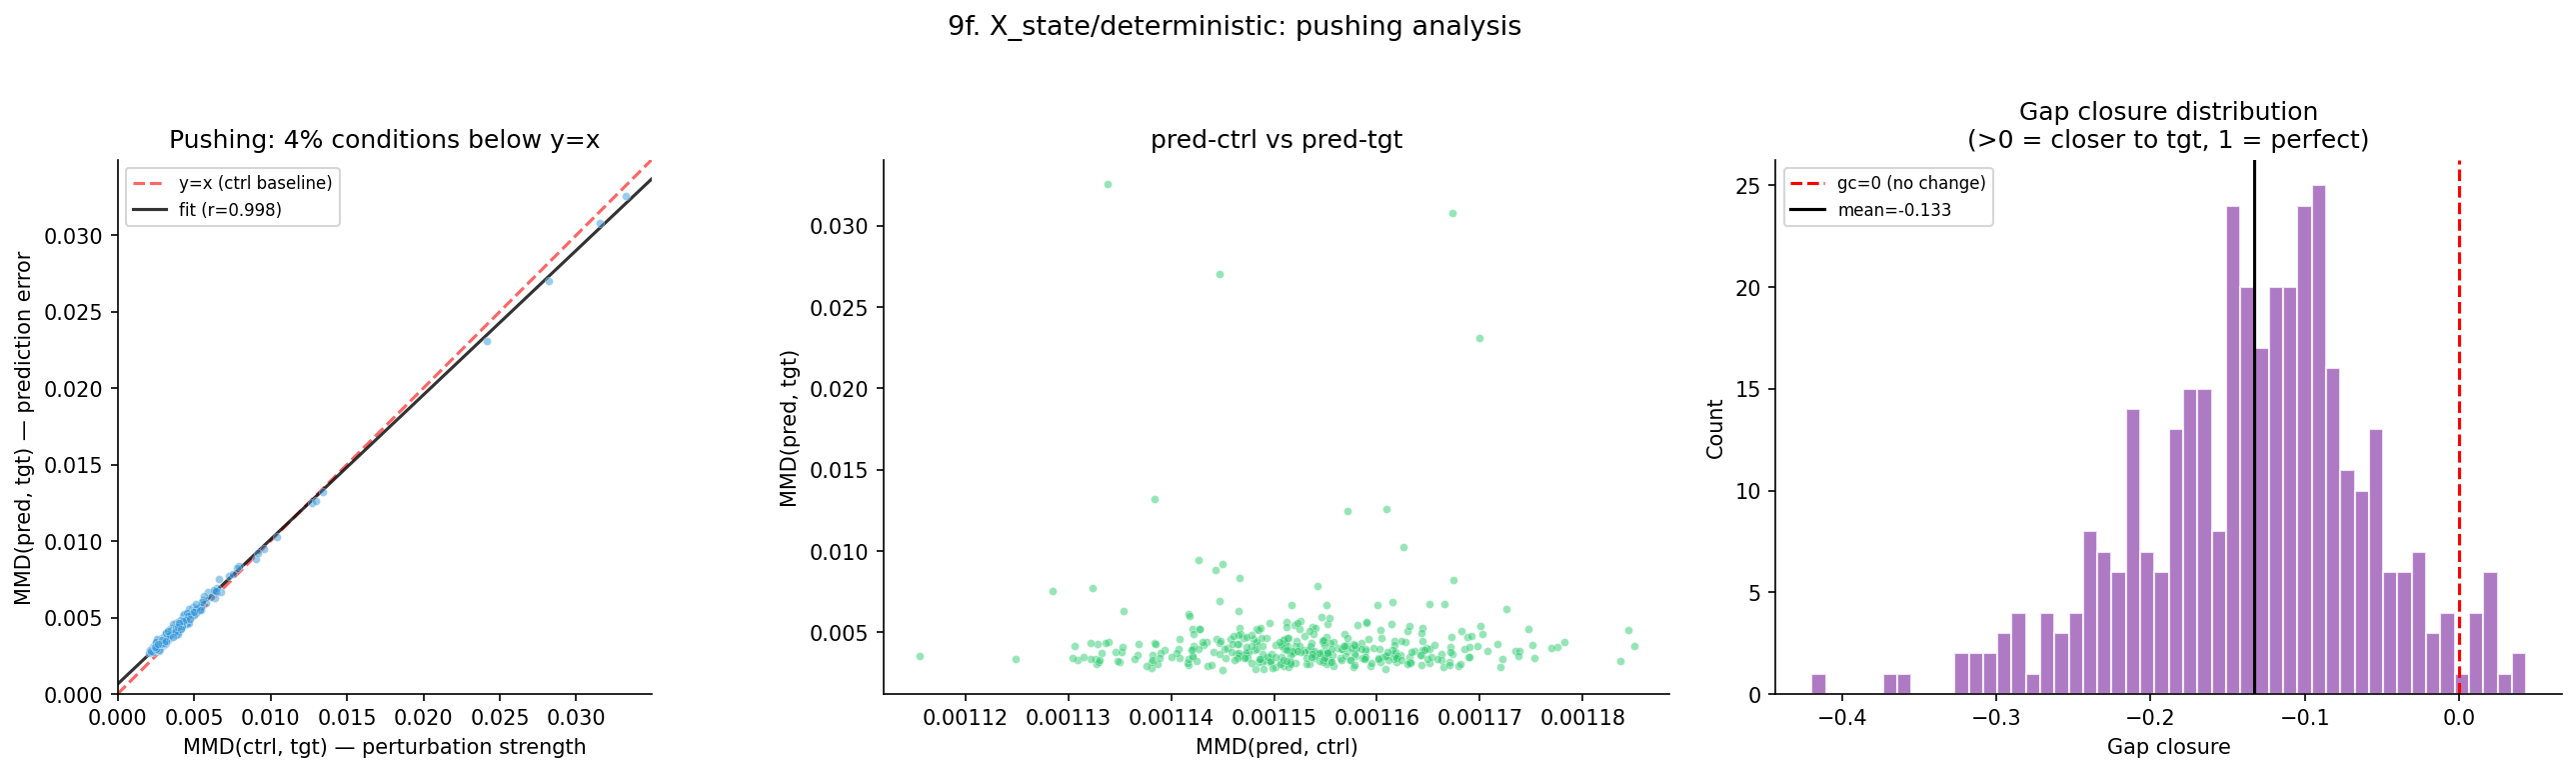

In [17]:
# ── 9f. Pushing analysis — scatter + regression ──
x = df_adhoc["mmd_ctrl_tgt"]
y = df_adhoc["mmd_pred_tgt"]

slope, intercept, r_val, _, _ = linregress(x, y)
frac_below = (y < x).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: perturbation strength vs prediction error
ax = axes[0]
ax.scatter(x, y, s=15, alpha=0.5, edgecolors="white", linewidth=0.3, color="#3498db", zorder=3)
lim = max(x.max(), y.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", alpha=0.6, lw=1.5, label="y=x (ctrl baseline)")
reg_x = np.array([0, lim])
ax.plot(reg_x, slope * reg_x + intercept, "k-", lw=1.5, alpha=0.8, label=f"fit (r={r_val:.3f})")
ax.set_xlabel("MMD(ctrl, tgt) — perturbation strength")
ax.set_ylabel("MMD(pred, tgt) — prediction error")
ax.set_title(f"Pushing: {frac_below:.0%} conditions below y=x")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect("equal", adjustable="box")
ax.legend(fontsize=8)

# Scatter: MMD(pred, ctrl) vs MMD(pred, tgt) — is the model doing something?
ax = axes[1]
ax.scatter(df_adhoc["mmd_pred_ctrl"], df_adhoc["mmd_pred_tgt"],
           s=15, alpha=0.5, edgecolors="white", linewidth=0.3, color="#2ecc71", zorder=3)
ax.set_xlabel("MMD(pred, ctrl)")
ax.set_ylabel("MMD(pred, tgt)")
ax.set_title("pred-ctrl vs pred-tgt")

# Gap closure histogram
ax = axes[2]
eps = 1e-8
gc = 1.0 - df_adhoc["mmd_pred_tgt"] / (df_adhoc["mmd_ctrl_tgt"] + eps)
ax.hist(gc, bins=50, color="#9b59b6", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", ls="--", lw=1.5, label="gc=0 (no change)")
ax.axvline(gc.mean(), color="k", ls="-", lw=1.5, label=f"mean={gc.mean():.3f}")
ax.set_xlabel("Gap closure"); ax.set_ylabel("Count")
ax.set_title("Gap closure distribution\n(>0 = closer to tgt, 1 = perfect)")
ax.legend(fontsize=8)

fig.suptitle(f"9f. {RUN_TAG}: pushing analysis", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# ── 9g. Summary table: delta MMD (pred vs baseline) per condition, sorted ──
df_adhoc["delta_mmd"] = df_adhoc["mmd_pred_tgt"] - df_adhoc["mmd_ctrl_tgt"]
df_adhoc["gap_closure"] = 1.0 - df_adhoc["mmd_pred_tgt"] / (df_adhoc["mmd_ctrl_tgt"] + 1e-8)

print(f"=== {RUN_TAG}: pushing summary ===")
print(f"  Conditions improved (delta < 0):  {(df_adhoc.delta_mmd < 0).sum()} / {len(df_adhoc)}")
print(f"  Conditions worsened (delta > 0):   {(df_adhoc.delta_mmd > 0).sum()} / {len(df_adhoc)}")
print(f"  Mean delta:  {df_adhoc.delta_mmd.mean():+.5f}")
print(f"  Mean gap closure: {df_adhoc.gap_closure.mean():.4f}")
print()

print("Top 10 best-pushed conditions:")
top10 = df_adhoc.nsmallest(10, "delta_mmd")[["drug_0", "mmd_ctrl_tgt", "mmd_pred_tgt", "delta_mmd", "gap_closure", "r_squared"]]
display(top10)

print("\nTop 10 worst conditions:")
bot10 = df_adhoc.nlargest(10, "delta_mmd")[["drug_0", "mmd_ctrl_tgt", "mmd_pred_tgt", "delta_mmd", "gap_closure", "r_squared"]]
display(bot10)

=== X_state/deterministic: pushing summary ===
  Conditions improved (delta < 0):  14 / 367
  Conditions worsened (delta > 0):   353 / 367
  Mean delta:  +0.00043
  Mean gap closure: -0.1329

Top 10 best-pushed conditions:


,drug_0,mmd_ctrl_tgt,mmd_pred_tgt,delta_mmd,gap_closure,r_squared
171,Harringtonine,0.028190,0.027022,-0.001169,0.041458,0.760987
174,Homoharringtonine,0.024147,0.023095,-0.001052,0.043569,0.797738
254,Panobinostat,0.031511,0.030812,-0.000699,0.022171,0.687715
119,Dinaciclib,0.033261,0.032571,-0.000690,0.020738,0.504330
318,TAK-901,0.012964,0.012597,-0.000368,0.028379,0.888982
47,Belinostat,0.013425,0.013204,-0.000221,0.016429,0.848970
116,Digitoxin,0.010455,0.010237,-0.000218,0.020830,0.899252
68,Bortezomib,0.009023,0.008813,-0.000210,0.023279,0.911611
247,Ouabain (Octahydrate),0.012701,0.012492,-0.000209,0.016464,0.893560
190,Ixazomib citrate,0.009556,0.009462,-0.000094,0.009787,0.913814



Top 10 worst conditions:


,drug_0,mmd_ctrl_tgt,mmd_pred_tgt,delta_mmd,gap_closure,r_squared
240,OTS514,0.002551,0.003622,0.001071,-0.419894,0.970112
268,Pimozide,0.003594,0.004607,0.001013,-0.281984,0.957874
326,Thymol,0.002483,0.003397,0.000914,-0.368299,0.973458
168,Glycyrrhizic acid,0.004658,0.005557,0.000899,-0.192958,0.943512
261,Pentoxifylline,0.004312,0.005205,0.000893,-0.207188,0.948793
259,Pentagastrin,0.006625,0.007516,0.000891,-0.134529,0.946628
359,XRK3F2,0.003267,0.004151,0.000884,-0.270435,0.964352
22,Allantoin,0.003789,0.004668,0.000879,-0.232088,0.956306
201,Lenalidomide (hemihydrate),0.002668,0.003533,0.000865,-0.324026,0.971036
160,Futibatinib,0.003452,0.004280,0.000828,-0.239926,0.961121


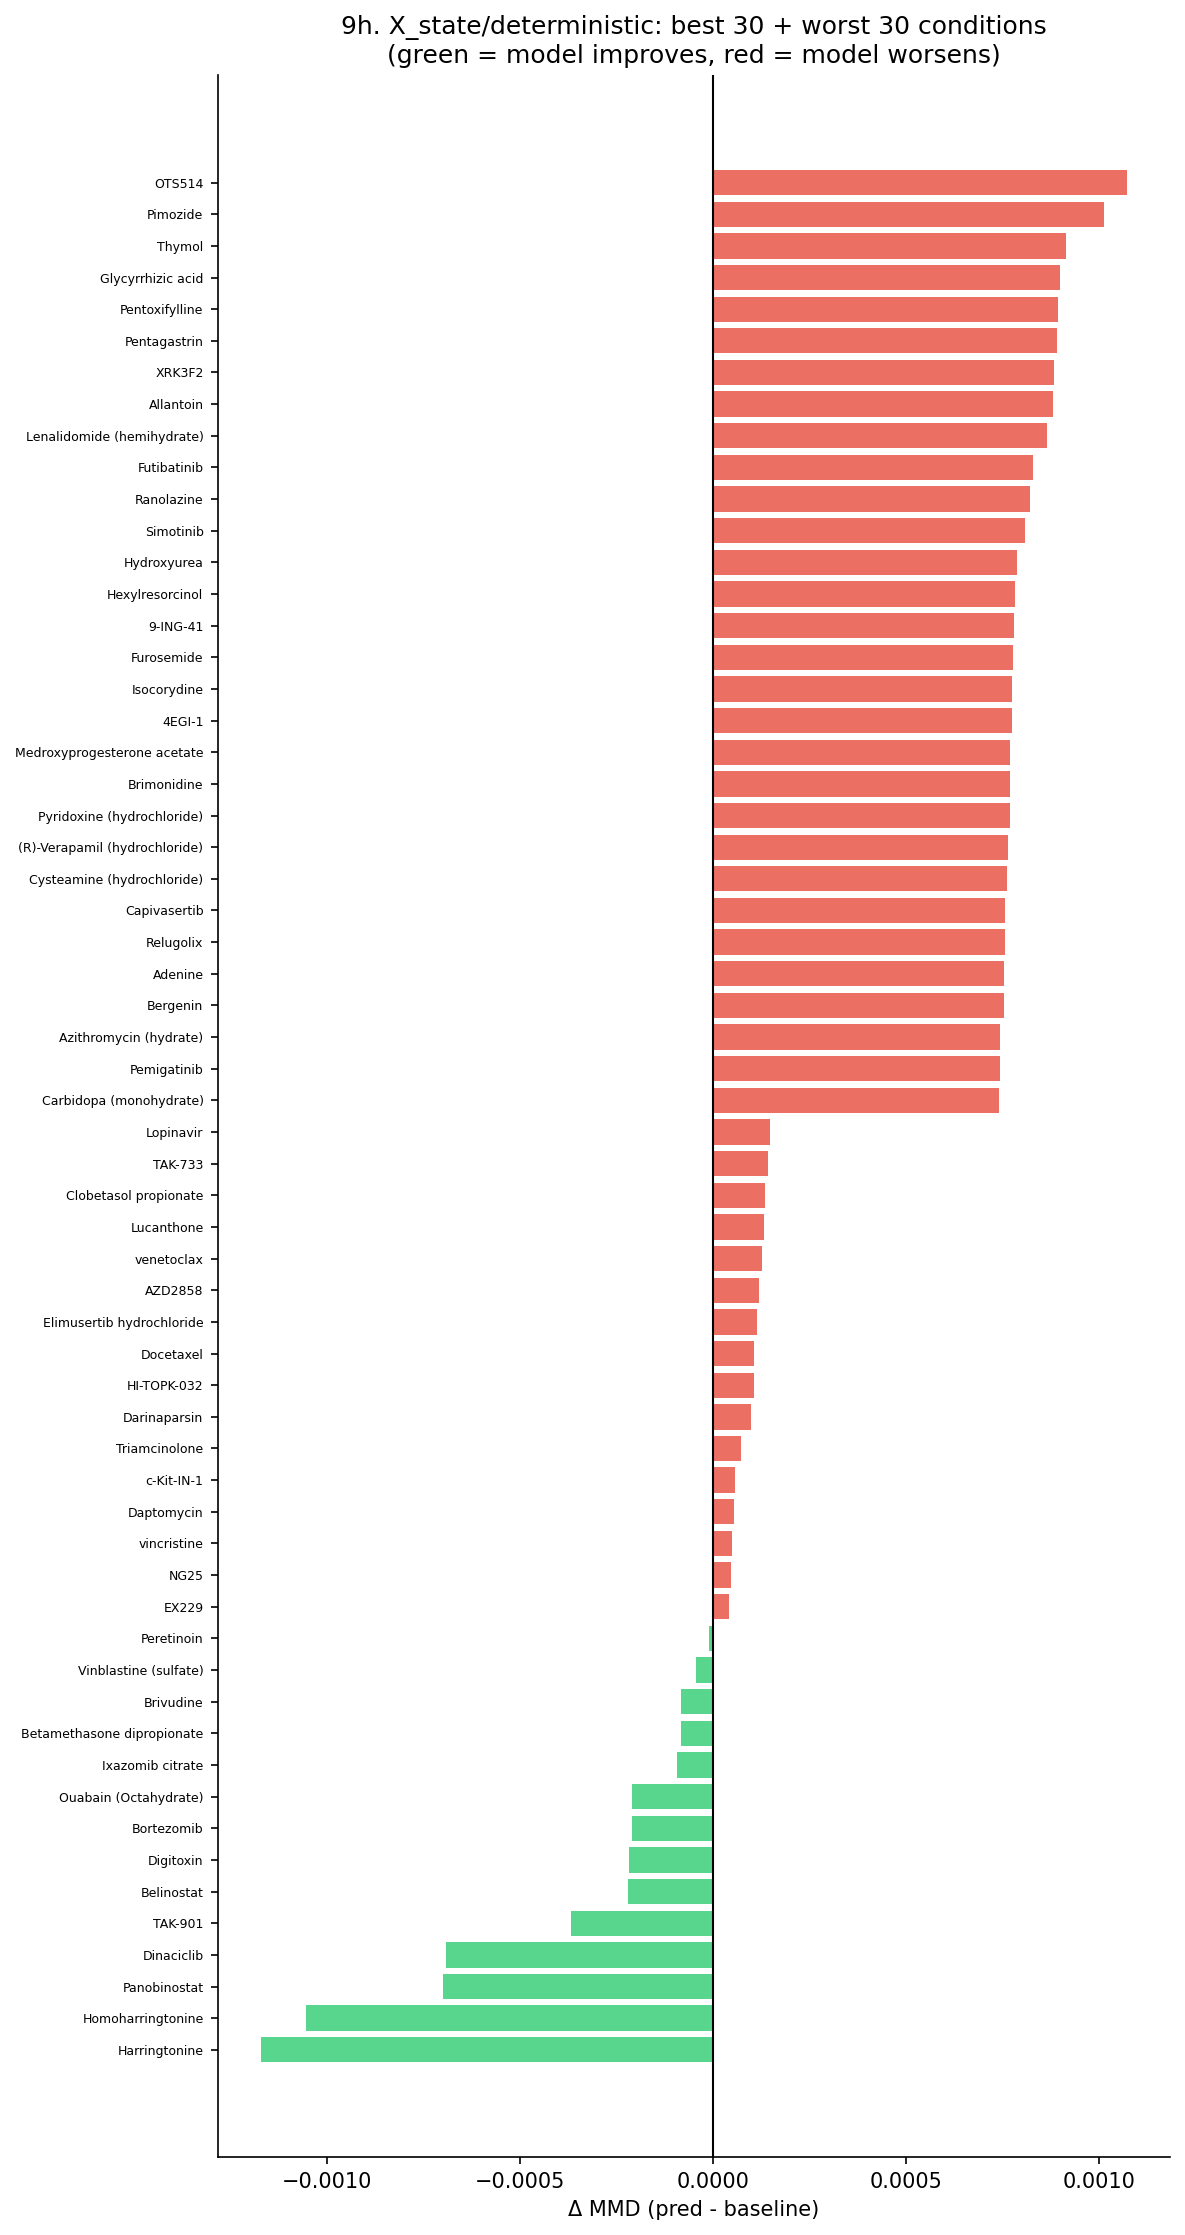

In [19]:
# ── 9h. Per-condition delta MMD bar chart (top 30 best + worst) ──
df_sorted = df_adhoc.sort_values("delta_mmd")
n_show = 30
top = pd.concat([df_sorted.head(n_show), df_sorted.tail(n_show)])

fig, ax = plt.subplots(figsize=(8, max(6, len(top) * 0.25)))
colors = ["#2ecc71" if d < 0 else "#e74c3c" for d in top["delta_mmd"]]
ax.barh(range(len(top)), top["delta_mmd"], color=colors, alpha=0.8)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["drug_0"].values, fontsize=6)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Δ MMD (pred - baseline)")
ax.set_title(f"9h. {RUN_TAG}: best {n_show} + worst {n_show} conditions\n(green = model improves, red = model worsens)")
plt.tight_layout()
plt.show()